In [37]:
import h5py
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid # for cumulative integration
from scipy.integrate import trapezoid 
import corner

# Loading Data

In [38]:
f = h5py.File('GW170817_GWTC-1.hdf5', 'r')
path = 'GW170817_GWTC-1.hdf5'
print(list(f.keys()))
print(type(f['IMRPhenomPv2NRT_highSpin_posterior']))
#print(type(f['Overall_posterior']))
#print(type(f['SEOBNRv3_posterior']))
#print(type(f['prior']))
post = f['IMRPhenomPv2NRT_highSpin_posterior']
print(post.dtype)

df = pd.read_hdf('GW170817_GWTC-1.hdf5', key='IMRPhenomPv2NRT_highSpin_posterior')
print(df.columns)
print(df.head(5))

['IMRPhenomPv2NRT_highSpin_posterior', 'IMRPhenomPv2NRT_highSpin_prior', 'IMRPhenomPv2NRT_lowSpin_posterior', 'IMRPhenomPv2NRT_lowSpin_prior']
<class 'h5py._hl.dataset.Dataset'>
[('costheta_jn', '<f8'), ('luminosity_distance_Mpc', '<f8'), ('right_ascension', '<f8'), ('declination', '<f8'), ('m1_detector_frame_Msun', '<f8'), ('m2_detector_frame_Msun', '<f8'), ('lambda1', '<f8'), ('lambda2', '<f8'), ('spin1', '<f8'), ('spin2', '<f8'), ('costilt1', '<f8'), ('costilt2', '<f8')]
Index(['costheta_jn', 'luminosity_distance_Mpc', 'right_ascension',
       'declination', 'm1_detector_frame_Msun', 'm2_detector_frame_Msun',
       'lambda1', 'lambda2', 'spin1', 'spin2', 'costilt1', 'costilt2'],
      dtype='str')
   costheta_jn  luminosity_distance_Mpc  right_ascension  declination  \
0    -0.994916                45.252574          3.44616    -0.408084   
1    -0.986352                45.872286          3.44616    -0.408084   
2    -0.805300                37.419041          3.44616    -0.408084

In [39]:
# to replicate the 2D histogram of H_0 and cos(iota) we need the luminosity distance(d_l) and cos(iota) samples
d_l = df['luminosity_distance_Mpc']
cos_iota = df['costheta_jn']

z = 0.009877        # redshift from https://ned.ipac.caltech.edu/byname?objname=ngc+4993&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1
# z_uncert = 1.67e-5 do we need to take this into account?

c = 299792.458      # speed of light in km/s from https://physics.nist.gov/cgi-bin/cuu/Value?c

# Visualizing Data

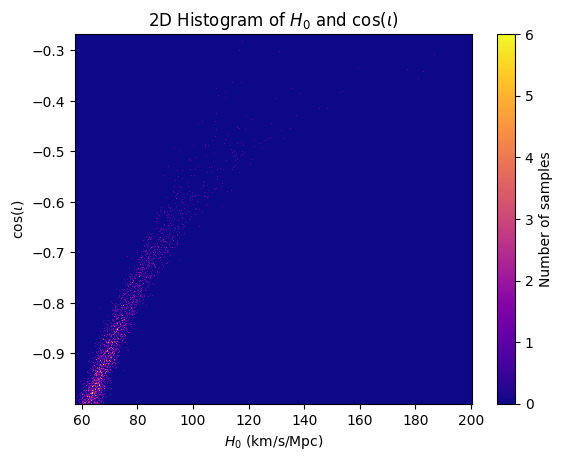

In [40]:
# low redshift approximation: d_L = (c/H_0) * z
H_0 = (c * z) / d_l

#Visualize the 2D distribution of H_0 and cos(iota)
plt.hist2d(H_0, cos_iota, bins=500, cmap = 'plasma', range=None, density=False, weights=None, cmin=None, cmax=None, data=None)
plt.colorbar(label='Number of samples')
plt.xlabel(r'$H_0$ (km/s/Mpc)')
plt.ylabel(r'cos($\iota$)')
plt.title(r'2D Histogram of $H_0$ and cos($\iota$)')
plt.show()

# Likelihood

In [41]:
# meshgrids used for evaluating the kde on a grid of points
# cos iota from -1 to 1, H_0 from min to max values of the samples

H_0_grid, cos_iota_grid = np.meshgrid(np.linspace(min(H_0), max(H_0), 100), np.linspace(-1, 1, 100))

# low redshift approximation: d_L = (c/H_0) * z
d_l_grid = (c * z) / H_0_grid

Computation of Jacobian:
$J = |\frac{\partial d_L}{\partial H_0}| = |-\frac{cz}{H_0^2}|$,

where we have used the low redshift approximation $d_L = \frac{cz}{H_0}$

In [42]:
def likelihood_function(bandwidth):
    """ 
    Compute the likelihood of the data given the model parameters (H_0, cos(iota)) using a kernel density estimate (kde) of the data.
    Makes use of the low redshift approximation to relate the luminosity distance to H_0 and the redshift.
    """ 
    
    data_l_d_cos_iota = np.vstack((d_l,cos_iota)) # needed because kde for 2D takes a 2D array of shape (# dims, # data)

    # kde model 
    kde = gaussian_kde(data_l_d_cos_iota,bw_method=bandwidth)

    # apply kde to the grid points
    # we need to ravel (flatten) the grid points and stack them into a 2D array of shape (# dims, # grid points) for the kde
    kde_values = kde(np.vstack([d_l_grid.ravel(), cos_iota_grid.ravel()]))

    # define jacobian for the transformation from (d_L, cos(iota)) to (H_0, cos(iota))
    J = (c * z) / (H_0_grid**2)

    # need to reshape the kde values back to the shape of the grid and multiply by the jacobian to get the likelihood in terms of (H_0, cos(iota))
    likelihood = kde_values.reshape(H_0_grid.shape) * J

    return likelihood


def log_likelihood(theta, likelihood):
    H0, cos_iota_val = theta

    # Extract grid axes
    H0_values = H_0_grid[0, :]
    cos_iota_values = cos_iota_grid[:, 0]

    # Reject out-of-bounds
    if H0 < H0_values.min() or H0 > H0_values.max():
        return -np.inf
    if cos_iota_val < cos_iota_values.min() or cos_iota_val > cos_iota_values.max():
        return -np.inf

    # Find nearest indices
    i = np.abs(cos_iota_values - cos_iota_val).argmin()
    j = np.abs(H0_values - H0).argmin()


    # Extract likelihood value
    like = likelihood[i, j]

    # Handle invalid values
    if like <= 0 or not np.isfinite(like):
        return -np.inf

    return np.log(like)

In [43]:
kde_bandwidths = [0.1,1,10]
likelihoods = [likelihood_function(bw) for bw in kde_bandwidths]

<Figure size 600x500 with 0 Axes>

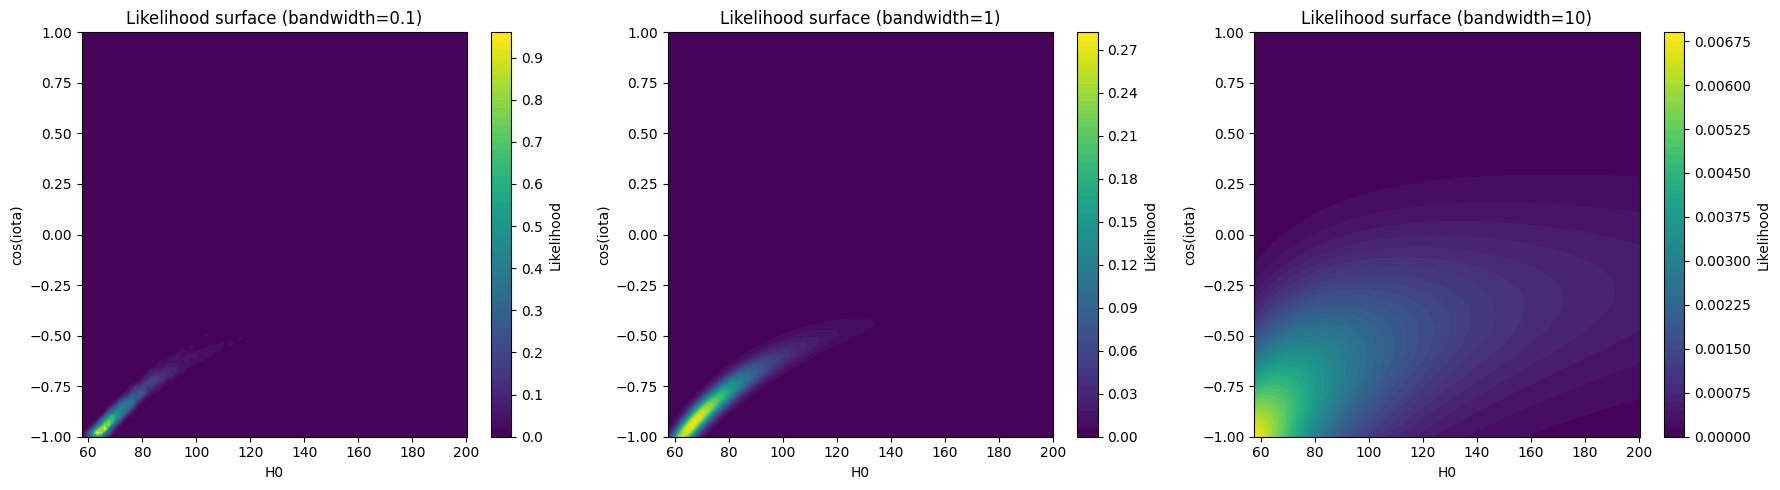

In [44]:
plt.figure(figsize=(6,5))
fig,ax = plt.subplots(1,3, figsize=(18,5))
for i, bw in enumerate(kde_bandwidths):
    ax[i].contourf(H_0_grid, cos_iota_grid, likelihoods[i], levels=50)
    ax[i].set_xlabel("H0")
    ax[i].set_ylabel("cos(iota)")
    ax[i].set_title(f"Likelihood surface (bandwidth={bw})")
    fig.colorbar(ax[i].collections[0], ax=ax[i], label="Likelihood")
plt.tight_layout()
plt.show()
# plt.contourf(H_0_grid, cos_iota_grid, likelihood, levels=50)
# plt.xlabel("H0")
# plt.ylabel("cos(iota)")
# plt.title("Likelihood surface")
# plt.colorbar(label="Likelihood")
# plt.show()

# Posterior

In [45]:
def log_prior(theta):
    H0, cos_iota = theta
    if 50 < H0 < 100 and -1 <= cos_iota <= 1:
        return -np.log(H0)
    return -np.inf

In [46]:
def sampler_2D(
    n_samples=5000,
    initial=[70, 0.0],
    proposal_width=[1, 0.05],
    likelihood = likelihoods[0]
):
    accepted_H_0 = []
    accepted_cos_iota = []
    n_accepted = 0
    acceptance_rates = []
    current = np.array(initial)
    chain = [current.copy()]

    for i in range(n_samples):

        # randomly propose new point
        proposal = np.array([
            np.random.normal(current[0], proposal_width[0]),  # H0
            np.random.normal(current[1], proposal_width[1])   # cos(iota)
        ])

        # get log likelihoods for comparison
        log_like_current = log_likelihood(current, likelihood)
        log_like_proposal = log_likelihood(proposal, likelihood)

        log_prior_current = log_prior(current)
        log_prior_proposal = log_prior(proposal)

        # set log posterior. because of small values, this is done with the addition of the logs instead of 
        # multiplying likelihoods in order to prevent breakdown
        log_post_current = log_like_current + log_prior_current
        log_post_proposal = log_like_proposal + log_prior_proposal

        # compute acceptance probability, then decide to take current or proposal
        # If proposal is invalid we reject immediately to avoid breakdown
        if not np.isfinite(log_post_current):
            accept = False

        # If current is invalid (should only activate if the very first initials are bad)
        elif not np.isfinite(log_post_proposal):
            accept = False

        else:
            log_p_accept = log_post_proposal - log_post_current
            accept = np.log(np.random.rand()) < log_p_accept

        if accept:
            current = proposal
            n_accepted += 1
    
        accepted_H_0.append(current[0])
        accepted_cos_iota.append(current[1])
        acceptance_rates.append(n_accepted/n_samples)

        chain.append(current.copy())

    return np.array(chain), accepted_H_0, accepted_cos_iota,n_accepted/n_samples

for a H_0 proposal width of 10 and a cos(iota) proposal width of 0.01, the acceptance rate is: 0.2775


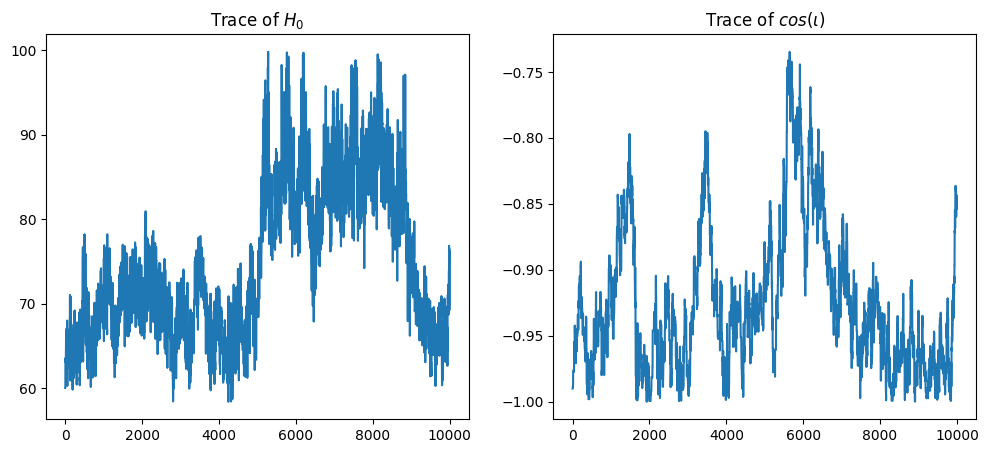

for a H_0 proposal width of 0.1 and a cos(iota) proposal width of 0.1, the acceptance rate is: 0.2033


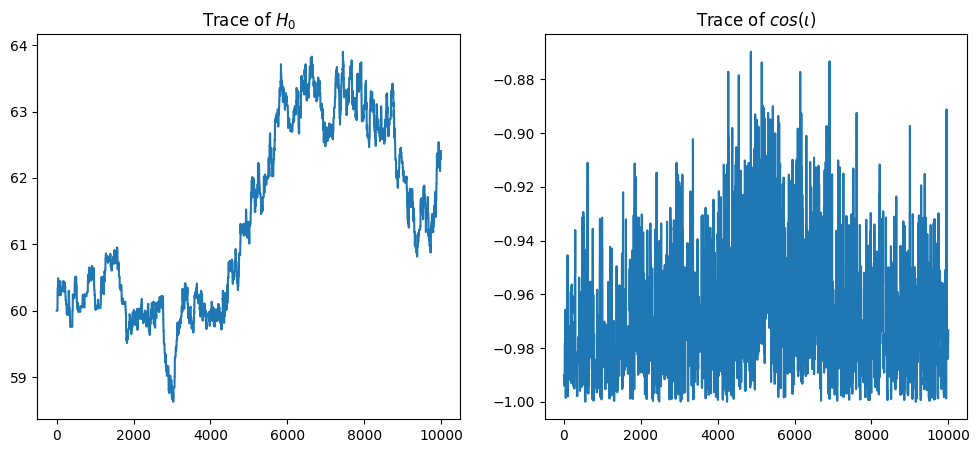

for a H_0 proposal width of 1 and a cos(iota) proposal width of 0.1, the acceptance rate is: 0.3322


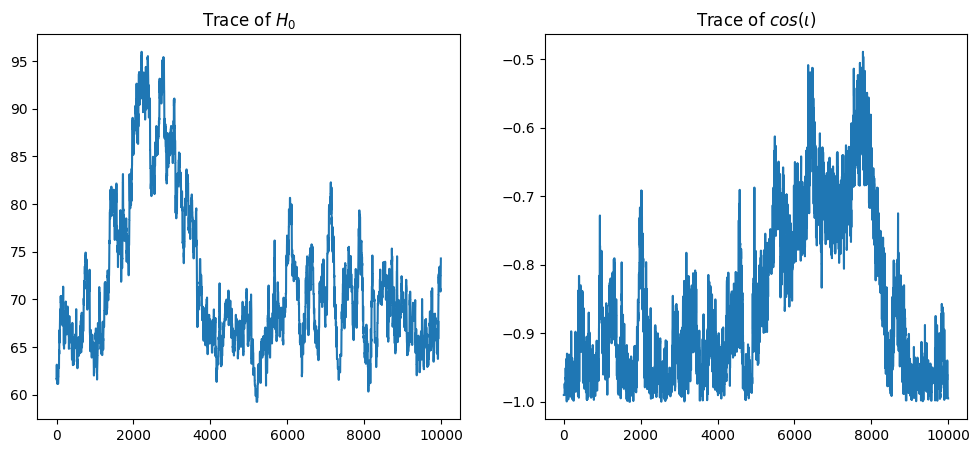

In [ ]:
# determine appropriate proposal width by looking at the acceptance rate.
# np.random.seed(30)
n_samples=10000
initial=[60, -0.99]
proposal_widths_H_0 = [0.01,0.1,1,10,100]
proposal_widths_c_i = [0.01,0.1,1,10,100]

proposal_widths= []
for i in proposal_widths_c_i:
    for j in proposal_widths_H_0:
        proposal_widths.append([j,i])

for proposal_width in proposal_widths:
    acceptance_rate = sampler_2D(n_samples, initial, proposal_width)[3]
    if acceptance_rate < 0.5 and acceptance_rate > 0.2:
        print(f"for a H_0 proposal width of {proposal_width[0]} and a cos(iota) proposal width of {proposal_width[1]}, the acceptance rate is: {acceptance_rate}")
        accepted_H_0 = sampler_2D(n_samples, initial, proposal_width)[1]

        accepted_cos_iota = sampler_2D(n_samples, initial, proposal_width)[2]

        fig, ax = plt.subplots(1, 2, figsize=(12, 5))
        ax[0].plot(accepted_H_0)
        ax[0].set_title(r"Trace of $H_0$")
        ax[1].plot(accepted_cos_iota)
        ax[1].set_title(r"Trace of $cos(\iota)$")
        plt.show()


In [87]:
# https://research-portal.uu.nl/ws/portalfiles/portal/248573031/PhysRevD.110.083033.pdf proposal width of 20%
proposal_width = [10, 0.01]

chain = sampler_2D(n_samples,initial,proposal_width)[0]

# Remove burn-in
burnin = int(n_samples/200)
burnin = 0
samples = chain[burnin:]

H0_samples = samples[:, 0]

median = np.median(H0_samples)
low, high = np.percentile(H0_samples, [16, 84])

print(f"H0 = {median:.2f} (+{high - median:.2f}, -{median - low:.2f})")

H0 = 70.42 (+11.41, -6.21)


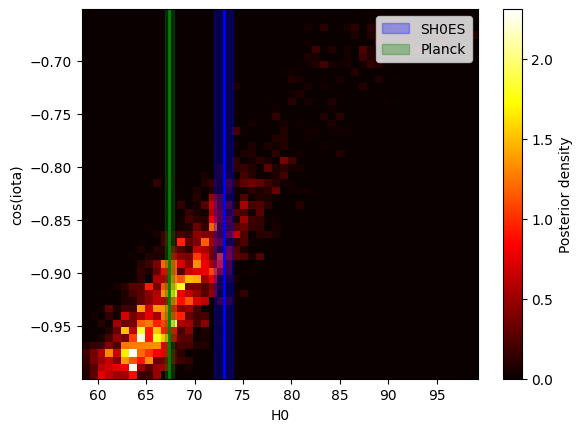

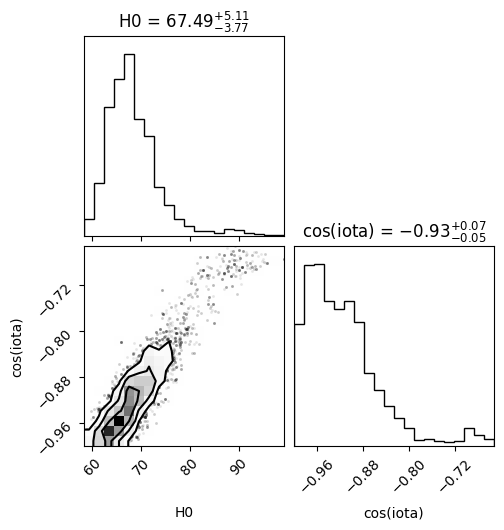

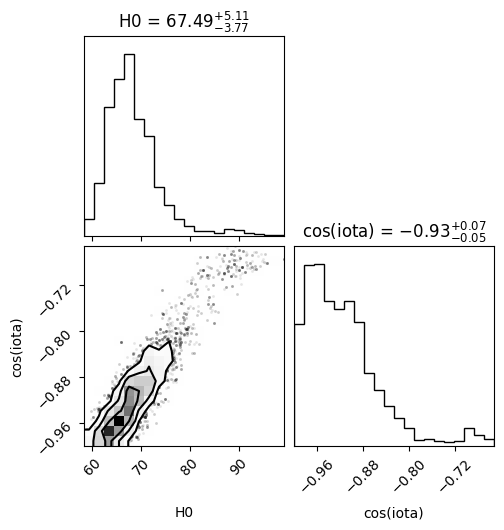

In [85]:
# the Planck and SH0ES values we cant to compare our findings to (CITATION NEEDED)

planck_mean = 67.4
planck_sigma = 0.5
shoes_mean = 73.0
shoes_sigma = 1.0


plt.hist2d(samples[:, 0], samples[:, 1], bins=50, density=True,cmap='hot')
plt.xlabel("H0")
plt.ylabel("cos(iota)")
plt.colorbar(label="Posterior density")

plt.axvspan(
    shoes_mean - shoes_sigma,
    shoes_mean + shoes_sigma,
    color='blue',
    alpha=0.3,
    label='SH0ES'
)
plt.axvline(shoes_mean, color='blue', linewidth=2)

plt.axvspan(
    planck_mean - planck_sigma,
    planck_mean + planck_sigma,
    color='green',
    alpha=0.3,
    label='Planck'
)
plt.axvline(planck_mean, color='green', linewidth=2)

plt.legend()
plt.show()

corner.corner(
    samples,
    labels=["H0", "cos(iota)"],
    show_titles=True
)